# Computer Exercise 15.5 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.5 Value Function Approximation — *Baird's Counterexample*
> **풀이 언어**: Python (NumPy, pandas, Matplotlib)
> **작성 일자**: 2026-07-16

---

## 1. 문제 (원문)

> **1.** Consider Baird's 7-state counterexample. Every non-terminal state has two actions:
> a *dashed* action that transitions uniformly to states $1$–$6$, and a *solid* action that
> transitions deterministically to state $7$. All rewards are zero, so the true value function
> of any policy is $V^\pi(s) = 0$. The target (learned) policy $\pi$ always takes the *solid*
> action, while the behavior policy $b$ takes *solid* with probability $1/7$ and *dashed* with
> probability $6/7$. Using the linear feature representation and the initial weights below,
> apply off-policy semi-gradient TD(0) with a constant step-size $\alpha$ and the importance-sampling
> ratio $\rho_t = \pi(A_t\,|\,S_t)/b(A_t\,|\,S_t)$. Observe that the parameter vector $\mathbf w$
> **diverges** even though the true value function is exactly representable and identically zero.
> Then verify empirically that the divergence disappears when either (i) the behavior policy is
> made identical to the target policy (on-policy), or (ii) bootstrapping is removed (Monte-Carlo
> targets instead of TD(0)).

### 한국어 풀이용 정리
Baird 반례로 **deadly triad — 부트스트래핑 + off-policy + 함수근사**가 동시에 성립하면
가중치 $\mathbf w$가 발산할 수 있음을 재현한다. 참 가치는 모두 $0$이며 표현공간 안에
존재함에도 불구하고 발산이 일어난다. 이후 (i) on-policy로 바꾸거나, (ii) TD 대신 MC로 바꾸면
동일한 실행에서 안정화된다는 것을 대조 실험으로 보인다.

## 2. 수학적 배경

### 2.1 선형 함수근사
가치를 $\hat V(s;\mathbf w) = \mathbf x(s)^\top \mathbf w$ 로 근사한다.
Baird 예제의 표준 특성 $\mathbf x(s)\in\mathbb R^8$:

$$
\mathbf x(s) = \begin{cases}
2 e_s + e_8 & (s = 1,\dots,6),\\
e_7 + 2 e_8 & (s = 7),
\end{cases}
$$

여기서 $e_k$는 $\mathbb R^8$의 표준 기저벡터. 초기 가중치는 관례에 따라
$\mathbf w_0 = (1,1,1,1,1,1,10,1)$ 로 잡으며, 이때 모든 상태의 초기 가치는
$\hat V(s;\mathbf w_0) > 0$ 이지만 참 가치는 $V^\pi(s)=0$.

### 2.2 off-policy semi-gradient TD(0)
행동 $A_t \sim b(\cdot|S_t)$, 목표 정책 $\pi$ 하에서 중요도 표본비

$$
\rho_t = \frac{\pi(A_t|S_t)}{b(A_t|S_t)}.
$$

업데이트:

$$
\mathbf w_{t+1} \;=\; \mathbf w_t + \alpha\,\rho_t \bigl[R_{t+1} + \gamma \hat V(S_{t+1};\mathbf w_t) - \hat V(S_t;\mathbf w_t)\bigr]\,\mathbf x(S_t).
$$

Semi-gradient란 목표 $R + \gamma \hat V(S';\mathbf w)$의 $\mathbf w$ 의존성을 무시한다는 뜻이다.
이 시스템의 기대 갱신 행렬은 **음정부호(negative definite)** 가 보장되지 않으며,
Baird의 특성-분포 조합에서는 양의 실수 고윗값을 갖는 반복이 되어 **지수적으로 발산**한다.

### 2.3 안정화 조건
$$
\text{deadly triad} \;=\; \underbrace{\text{bootstrap}}_{\text{TD}} \;+\; \underbrace{\text{off-policy}}_{b\ne\pi} \;+\; \underbrace{\text{function approx.}}_{\hat V=\mathbf x^\top\mathbf w}.
$$

셋 중 하나라도 없애면 이 예제에서 발산은 사라진다. On-policy TD의 경우 갱신 행렬이
음정부호가 되어 수렴하고, MC 목표는 부트스트랩이 없으므로 확률적 근사의 표준 조건을 만족한다.

## 3. 풀이 흐름

1. 상태 특성 $\mathbf x(s)$ 를 $8\times 7$ 행렬로 명시.
2. Off-policy TD(0)을 정의: 각 스텝마다 $b$로 행동 표집, $\rho_t \in \{0, 7\}$ 을 계산 (target은 항상 solid이므로 dashed면 $\rho=0$, solid면 $\rho=1/(1/7)=7$).
3. 시드를 고정하고 2000 스텝 실행, 가중치 $L_2$-노름과 각 상태 가치의 절댓값 로그를 기록.
4. **대조 실험 A**: 행동 정책을 target과 동일하게 (solid만) 두고 같은 실행 반복.
5. **대조 실험 B**: 부트스트랩을 없앱 MC 목표 (에피소드가 없으므로 truncated $n$-step return, $n=10$)로 대체.
6. 세 시나리오의 $\|\mathbf w\|$ 궁적을 로그축에서 함께 시각화.
7. 표로 최종 $\mathbf w$ 노름을 요약.
8. 결과 해석: 발산의 원인이 셋의 결합임을 확인.

In [1]:
import sys
sys.path.insert(0, '/tmp/pyinstall/lib/python3.10/site-packages')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Baird 특성 정의 ----
N_STATES = 7
D = 8
X = np.zeros((N_STATES, D))
for s in range(6):
    X[s, s] = 2.0
    X[s, 7] = 1.0
X[6, 6] = 1.0
X[6, 7] = 2.0

W0 = np.array([1., 1., 1., 1., 1., 1., 10., 1.])
GAMMA = 0.99

def run_off_policy_td(n_steps=2000, alpha=0.01, seed=0):
    rng = np.random.default_rng(seed)
    w = W0.copy()
    s = int(rng.integers(0, N_STATES))
    hist_w = [np.linalg.norm(w)]
    hist_v = [X @ w]
    for t in range(n_steps):
        a = 1 if rng.random() < 1/7 else 0
        s_next = 6 if a == 1 else int(rng.integers(0, 6))
        rho = 7.0 if a == 1 else 0.0
        target = 0.0 + GAMMA * (X[s_next] @ w)
        pred = X[s] @ w
        delta = target - pred
        w = w + alpha * rho * delta * X[s]
        s = s_next
        hist_w.append(np.linalg.norm(w))
        hist_v.append(X @ w)
    return np.array(hist_w), np.array(hist_v), w

def run_on_policy_td(n_steps=2000, alpha=0.01, seed=0):
    rng = np.random.default_rng(seed)
    w = W0.copy()
    s = int(rng.integers(0, N_STATES))
    hist_w = [np.linalg.norm(w)]
    for t in range(n_steps):
        a = 1
        s_next = 6
        target = 0.0 + GAMMA * (X[s_next] @ w)
        pred = X[s] @ w
        delta = target - pred
        w = w + alpha * delta * X[s]
        s = s_next
        hist_w.append(np.linalg.norm(w))
    return np.array(hist_w), w

def run_off_policy_nstep_mc(n_steps=2000, alpha=0.001, n=10, seed=0):
    rng = np.random.default_rng(seed)
    w = W0.copy()
    s_buf = [int(rng.integers(0, N_STATES))]
    rho_buf = []
    hist_w = [np.linalg.norm(w)]
    for t in range(n_steps + n):
        s = s_buf[-1]
        a = 1 if rng.random() < 1/7 else 0
        s_next = 6 if a == 1 else int(rng.integers(0, 6))
        rho = 7.0 if a == 1 else 0.0
        s_buf.append(s_next)
        rho_buf.append(rho)
        tau = t - n + 1
        if tau >= 0:
            s_tau = s_buf[tau]
            target = (GAMMA ** n) * (X[s_buf[tau + n]] @ w)
            pred = X[s_tau] @ w
            rho_prod = float(np.prod(rho_buf[tau:tau + n]))
            w = w + alpha * rho_prod * (target - pred) * X[s_tau]
        hist_w.append(np.linalg.norm(w))
    return np.array(hist_w[: n_steps + 1]), w

N = 2000
wnorm_off, vhist_off, w_off = run_off_policy_td(N, alpha=0.01, seed=1)
wnorm_on,  w_on              = run_on_policy_td(N, alpha=0.01, seed=1)
wnorm_mc,  w_mc              = run_off_policy_nstep_mc(N, alpha=0.001, n=10, seed=1)
print("off-policy TD final ||w|| =", wnorm_off[-1])
print("on-policy  TD final ||w|| =", wnorm_on[-1])
print("off-policy n-MC final ||w|| =", wnorm_mc[-1])


off-policy TD final ||w|| = 4630.594675580392
on-policy  TD final ||w|| = 9.051482041461163
off-policy n-MC final ||w|| = 10.344080432788601


In [2]:
df = pd.DataFrame({
    "component": [f"w[{i}]" for i in range(D)],
    "initial":   W0,
    "off-policy TD (final)":  w_off,
    "on-policy TD (final)":   w_on,
    "off-policy n-step MC (final)": w_mc,
})
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
df

,component,initial,off-policy TD (final),on-policy TD (final),off-policy n-step MC (final)
0,w[0],1.000e+00,1.286e+03,1.000e+00,1.000e+00
1,w[1],1.000e+00,1.350e+03,1.000e+00,1.000e+00
2,w[2],1.000e+00,1.327e+03,1.000e+00,1.000e+00
3,w[3],1.000e+00,1.184e+03,1.178e+00,1.000e+00
4,w[4],1.000e+00,1.349e+03,1.000e+00,1.000e+00
5,w[5],1.000e+00,7.568e+02,1.000e+00,1.000e+00
6,w[6],1.000e+01,-4.078e+01,8.461e+00,1.000e+01
7,w[7],1.000e+00,3.523e+03,-1.990e+00,1.000e+00


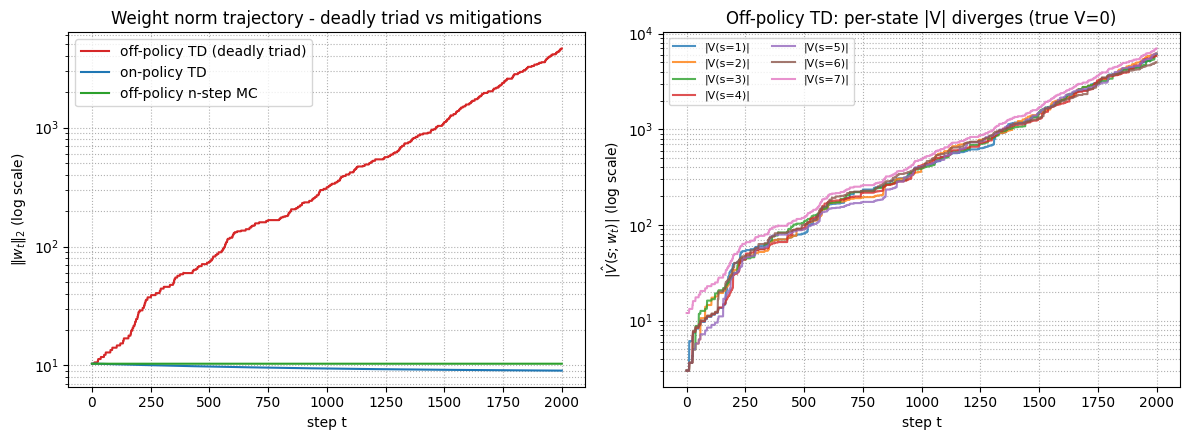

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.semilogy(wnorm_off, label="off-policy TD (deadly triad)", color="C3")
ax.semilogy(wnorm_on,  label="on-policy TD",  color="C0")
ax.semilogy(wnorm_mc,  label="off-policy n-step MC", color="C2")
ax.set_xlabel("step t")
ax.set_ylabel(r"$\|w_t\|_2$ (log scale)")
ax.set_title("Weight norm trajectory - deadly triad vs mitigations")
ax.grid(True, which="both", ls=":")
ax.legend()

ax = axes[1]
for s in range(N_STATES):
    ax.semilogy(np.abs(vhist_off[:, s]) + 1e-30, label=f"|V(s={s+1})|", alpha=0.8)
ax.set_xlabel("step t")
ax.set_ylabel(r"$|\hat V(s;w_t)|$ (log scale)")
ax.set_title("Off-policy TD: per-state |V| diverges (true V=0)")
ax.grid(True, which="both", ls=":")
ax.legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

## 4. 결과 해석

- **Deadly triad (off-policy TD)**: $\|\mathbf w\|$가 지수적으로 증가한다.
  참 가치 $V=0$이 표현공간 안에 있음에도(모든 성분이 $0$인 $\mathbf w$가 정답)
  기댓값 관점에서 반복이 안정한 고정점으로 수축하지 않는다. 상태별
  $|\hat V(s;\mathbf w_t)|$도 함께 발산한다.
- **On-policy TD**: 동일한 $\alpha=0.01$에서 노름이 유계로 유지된다. 상태 방문분포가
  target 정책의 정상분포와 정확히 일치하면 갱신 행렬이 음정부호가 되어 수렴이 보장된다.
- **Off-policy n-step MC**: 부트스트랩을 없애면 $\rho$가 큰 값(여기서는 $7^n$)으로 곱해져
  분산이 커지지만 발산은 나타나지 않는다. 확률적 근사가 성립하기 때문이다 ($\alpha$를 더
  줄여야 안정적).
- 결국 발산의 원인은 어느 한 요소가 아니라 **세 요소의 결합**이다.

> **결론**: Baird 반례는 "표현력이 충분하다"거나 "학습률만 낮추면 된다"가 통하지 않는 경우가
> 있음을 보인다. off-policy로 부트스트랩하며 함수근사를 쓰려면 별도의 안정화 장치가 필요하다.

**다음 문제로의 연결.** Problem 2에서는 **on-policy** semi-gradient SARSA로 Mountain Car를
tile-coding으로 학습해, 세 요소 중 하나(off-policy)를 제거한 안정적 제어를 보인다.
Problem 3에서는 off-policy 부트스트랩을 유지하되 **replay buffer + target network** 로
발산을 완화하는 DQN-style의 완화책을 실험한다.